In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('car_price.csv')

In [ ]:
#How many rows and columns does the dataset have?
df.shape

(2500, 10)

In [4]:
# Which features are numerical? Which are categorical?
df.dtypes

Car ID            int64
Brand            object
Year              int64
Engine Size     float64
Fuel Type        object
Transmission     object
Mileage           int64
Condition        object
Price           float64
Model            object
dtype: object

In [5]:
#Are there any missing values? How many, and in which columns?
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

Text(0.5, 0, 'Price')

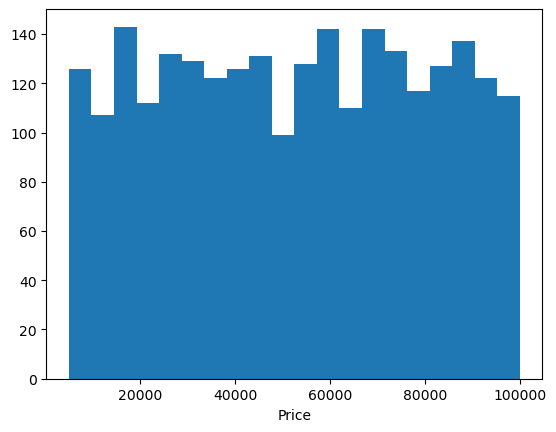

In [8]:
#What does the distribution of car prices look like?
import matplotlib.pyplot as plt
plt.hist(df['Price'], bins=20)
plt.xlabel('Price')

In [10]:
#Which features seem most related to price?
correlation_matrix = df.corr(numeric_only=True)
correlation_with_price = correlation_matrix['Price'].sort_values(ascending=False)
print(correlation_with_price)

Price          1.000000
Car ID         0.004650
Engine Size   -0.004420
Mileage       -0.008567
Year          -0.036805
Name: Price, dtype: float64


In [16]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [17]:
#Handle missing values — drop rows, fill with mean/mode, or another strategy. Justify your choice.
numerical_features = ['Year', 'Engine Size', 'Mileage', 'Price']
categorical_features = ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']

from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='mean')
df[numerical_features] = num_imputer.fit_transform(df[numerical_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

In [18]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [21]:
#- Encode categorical columns — use Label Encoding or One-Hot Encoding. Explain which and why.
from sklearn.preprocessing import LabelEncoder           

le = LabelEncoder()
df['Transmission_encoded'] = le.fit_transform(df['Transmission'])

df_encoded = pd.get_dummies(df, columns=['Brand', 'Fuel Type', 'Condition', 'Model'], drop_first=True)

df_final = df_encoded.drop(['Car ID', 'Transmission'], axis=1)

df_final.head()


,Year,Engine Size,Mileage,Price,Transmission_encoded,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016.0,2.3,114832.0,26613.92,1,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,2018.0,4.4,143190.0,14679.61,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2013.0,4.5,181601.0,44402.61,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2011.0,4.1,68682.0,86374.33,0,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,2009.0,2.6,223009.0,73577.10,1,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [22]:
#Scale numerical features — important for KNN. Use StandardScaler or MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = ['Year', 'Engine Size', 'Mileage', 'Price']

df_normalized = df.copy()
df_normalized[num_cols] = scaler.fit_transform(df[num_cols])

df_normalized[num_cols].head()

,Year,Engine Size,Mileage,Price
0,0.695652,0.26,0.382785,0.227465
1,0.782609,0.68,0.477326,0.101803
2,0.565217,0.70,0.605384,0.414771
3,0.478261,0.62,0.228927,0.856712
4,0.391304,0.32,0.743432,0.721964


In [23]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

df_standardized = df.copy()
df_standardized[num_cols] = std_scaler.fit_transform(df[num_cols])

df_standardized[num_cols].head()

,Year,Engine Size,Mileage,Price
0,0.625610,-0.813848,-0.397234,-0.953600
1,0.911720,0.652872,-0.074626,-1.390908
2,0.196444,0.722716,0.362347,-0.301770
3,-0.089667,0.443340,-0.922249,1.236198
4,-0.375778,-0.604316,0.833415,0.767270


In [24]:
#Detect and handle outliers — use boxplots or the IQR method.
import numpy as np
num_cols = ['Year', 'Engine Size', 'Mileage', 'Price']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"Column {col}: Found {outliers_count} outliers")
    

    df[col] = np.where(df[col] > upper_bound, upper_bound,
              np.where(df[col] < lower_bound, lower_bound, df[col]))



Column Year: Found 0 outliers
Column Engine Size: Found 0 outliers
Column Mileage: Found 0 outliers
Column Price: Found 0 outliers


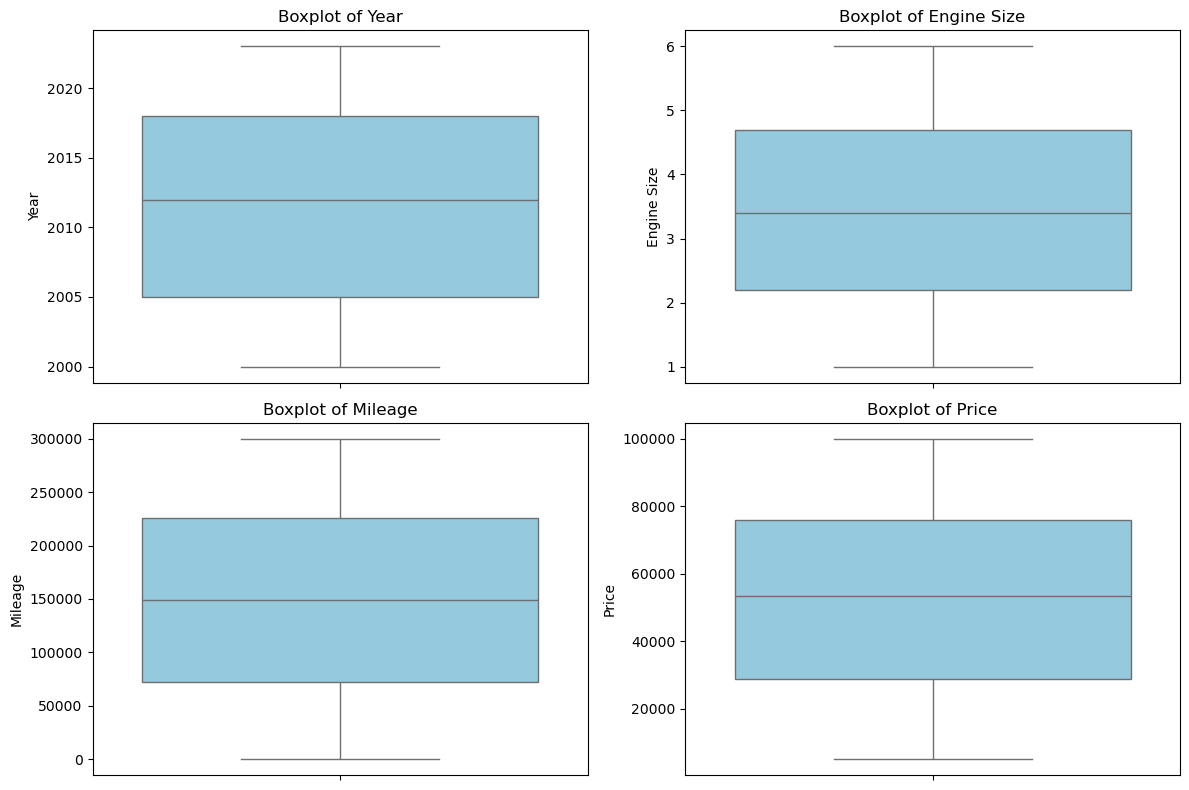

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()